# Country Socio-Economic Segmentation — Week 3
### Unsupervised Clustering · Dimensionality Reduction · Supervised Classification
**Dataset:** Country Health & Economic Indicators (`Country-data.csv`)  
**Objective:** Group countries into developmental tiers using clustering, then train classifiers to predict tier membership.

## 1. Environment Setup

In [1]:
# Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
SEED = 42

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Inspect the Dataset

### Upload the Dataset\nTo proceed, please upload the `Country-data.csv` file to your Colab environment.

In [8]:
from google.colab import files

# This will open a file dialog to let you upload the file.
# If the file is already uploaded, you can skip this step.
files.upload()

Saving Country-data.csv to Country-data.csv


{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\nAfghanistan,155.68814603309215,77.7,7.5,88.8,1492,4.3,57.95307690566236,6.844332935842271,5009\nAlbania,90.3,43.5,8.6,28.8,7380,5.0,69.5,3.22,6914\nAlgeria,39.5,45.2,2.4,28.2,5438,0.1,85.0,4.81,1591\nAngola,52.37023574792701,38.5,5.0,33.0,922,5.4,44.89444964208865,3.5264700624234973,23068\nArgentina,134.1717128400984,2.0,4.6,5.0,3358,1.0,62.450763723749674,4.352188038017047,606\nArmenia,5.1,39.5,4.0,34.5,7344,16.2,59.6,2.41,500\nAustralia,170.51449082351985,41.2,11.3,29.8,600,0.8,41.50668475723902,6.7705260938193,3991\nAustria,60.3,89.3,7.2,48.0,5722,2.7,85.0,4.92,11629\nAzerbaijan,95.71094934115247,36.2,2.2,51.8,1346,0.4,42.53552071123041,5.200551157152139,26612\nBahamas,36.9,46.0,8.8,82.5,5912,28.8,85.0,3.07,1642\nBahrain,83.38095380366603,39.3,12.4,64.0,1193,3.5,47.12182254904807,4.575514877242004,12116\nBangladesh,154.39336671824623,16.6,9.1,33.5,600,4.5,53.47903191688136,4.

In [9]:
df = pd.read_csv('Country-data.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (136, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,155.688146,77.7,7.5,88.8,1492,4.3,57.953077,6.844333,5009
1,Albania,90.300000,43.5,8.6,28.8,7380,5.0,69.500000,3.220000,6914
2,Algeria,39.500000,45.2,2.4,28.2,5438,0.1,85.000000,4.810000,1591
3,Angola,52.370236,38.5,5.0,33.0,922,5.4,44.894450,3.526470,23068
4,Argentina,134.171713,2.0,4.6,5.0,3358,1.0,62.450764,4.352188,606


In [10]:
df.info()
print()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     136 non-null    object 
 1   child_mort  136 non-null    float64
 2   exports     136 non-null    float64
 3   health      136 non-null    float64
 4   imports     136 non-null    float64
 5   income      136 non-null    int64  
 6   inflation   136 non-null    float64
 7   life_expec  136 non-null    float64
 8   total_fer   136 non-null    float64
 9   gdpp        136 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 10.8+ KB



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,136.00,136.00,136.00,136.00,136.00,136.00,136.00,136.00,136.00
mean,84.68,41.61,6.25,43.99,5609.07,4.24,58.84,4.53,8404.45
std,50.93,19.83,2.61,21.00,8201.30,4.48,11.63,1.45,12597.83
min,2.00,2.00,1.00,5.00,600.00,0.10,40.30,1.00,500.00
25%,49.85,25.28,4.28,28.10,1307.75,1.10,50.25,3.67,1615.00
50%,82.35,43.50,6.20,42.85,2920.50,2.75,57.92,4.58,3973.00
75%,126.51,53.22,8.00,58.02,6061.00,5.43,63.86,5.52,10499.75
max,178.86,100.00,12.50,100.00,56101.00,28.80,85.00,6.97,71088.00


In [11]:
print('Null counts:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Null counts:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


## 3. Data Cleaning
Four steps were applied:
1. **Column name trimming** — removes invisible whitespace that causes `KeyError` at runtime.
2. **Deduplication** — ensures one record per country.
3. **Type coercion** — non-numeric strings in numeric columns are silently converted to `NaN`.
4. **Median imputation** — preferred over mean for economic variables (`gdpp`, `income`) because their distributions are strongly right-skewed, making the median a more representative central value.

In [12]:
# Trim headers
df.columns = df.columns.str.strip()

# Drop exact duplicates
df = df.drop_duplicates()

# Coerce non-numeric fields
for col in df.select_dtypes(include='object').columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill remaining NaNs with column medians
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

print(f'Cleaned shape: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Cleaned shape: (136, 10)
Remaining nulls: 0


## 4. Exploratory Data Analysis

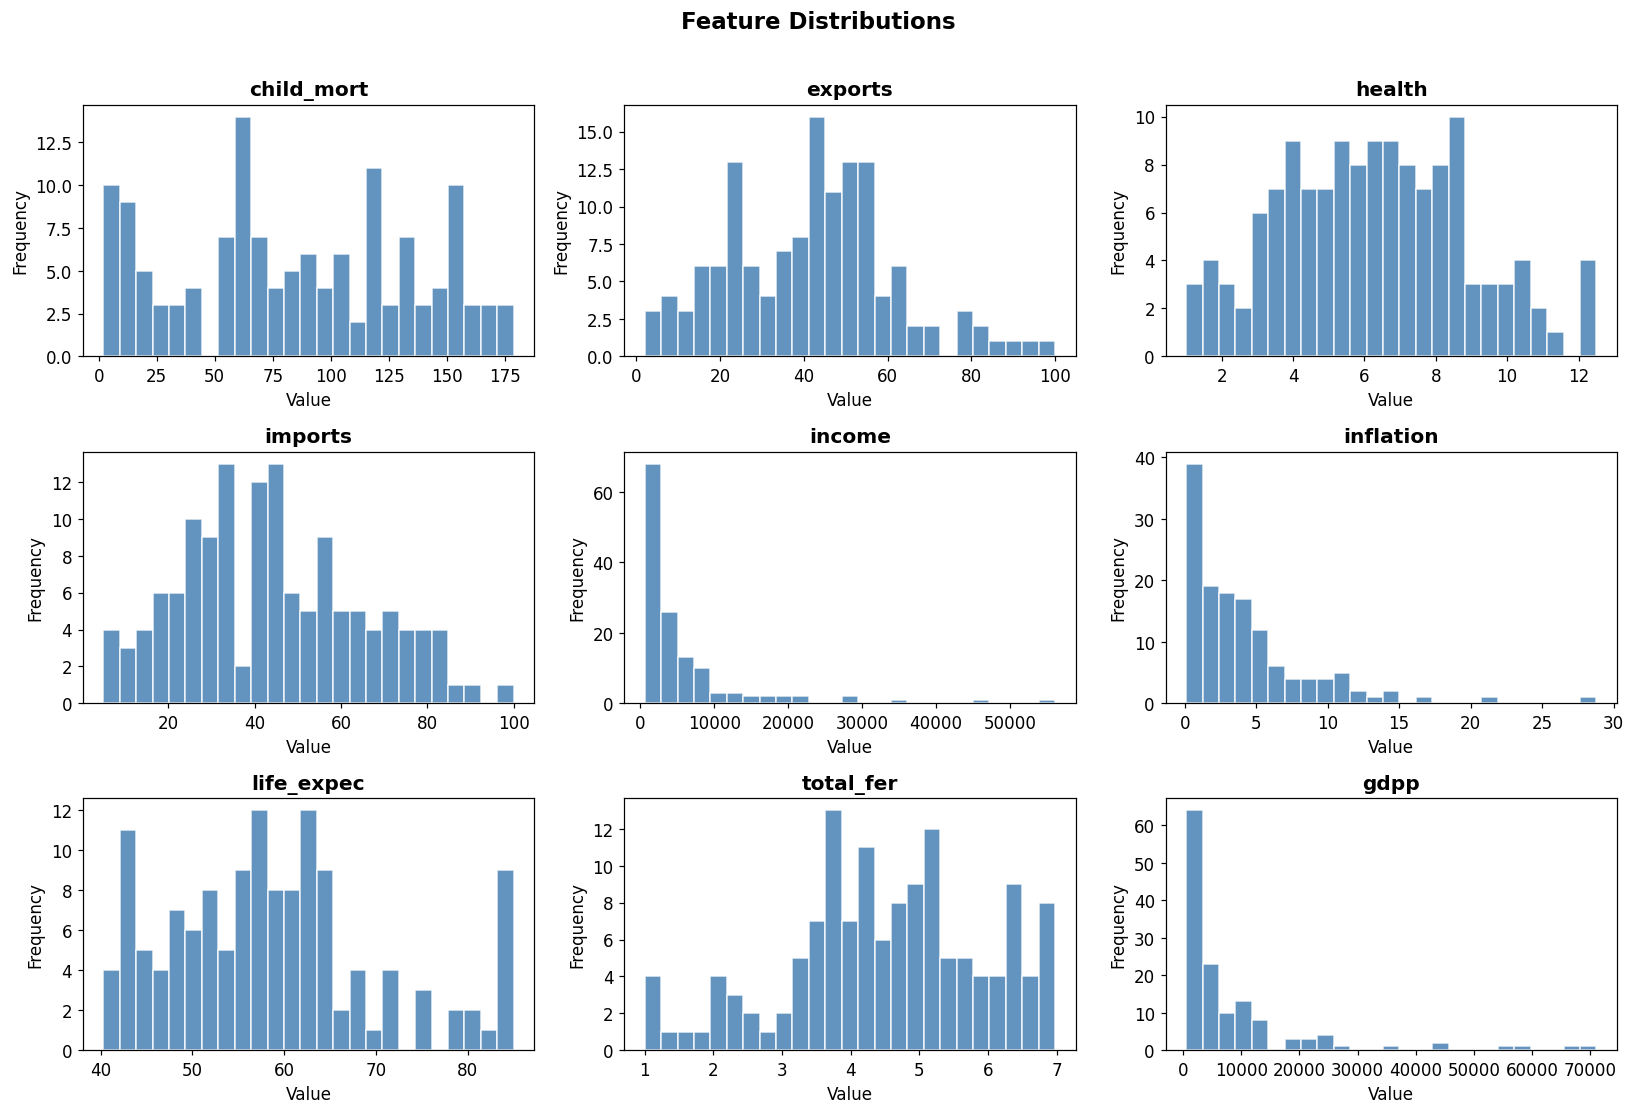

In [13]:
features = df.drop(columns=['country'])

# Histograms for each numeric feature
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features.columns):
    axes[i].hist(features[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

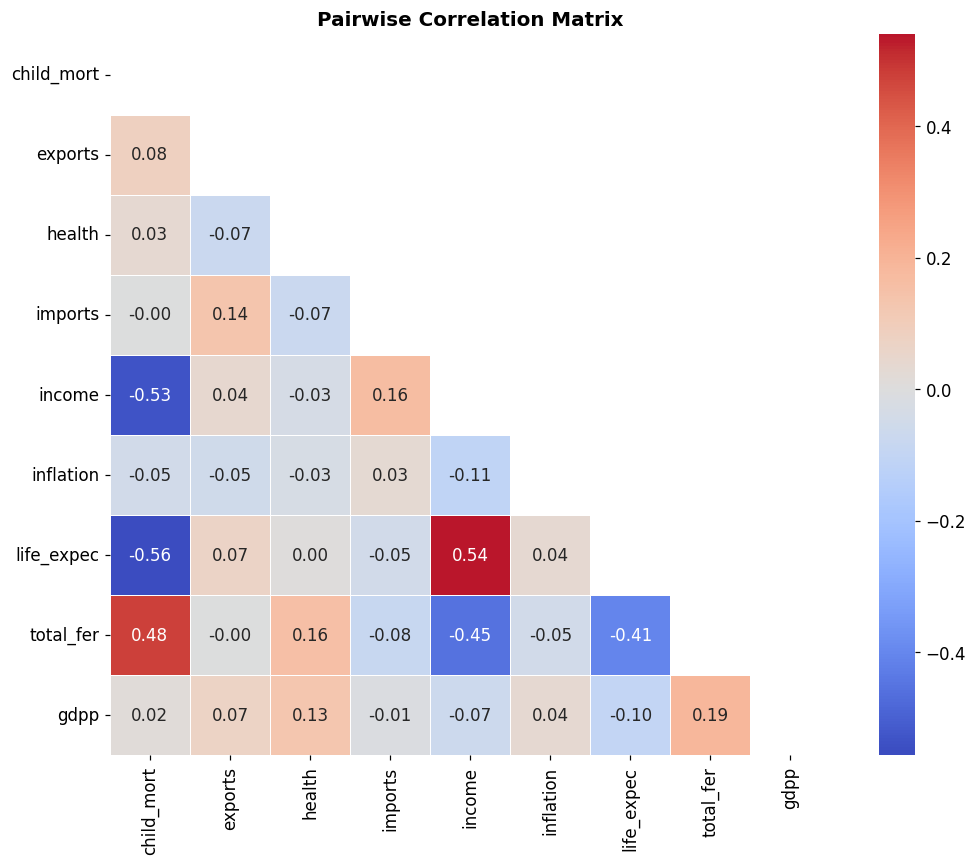

In [14]:
# Correlation heatmap (lower triangle only)
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Pairwise Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation findings:**  
`child_mort` is strongly negatively correlated with `income`, `gdpp`, and `life_expec`, reflecting that wealthier countries have better child survival outcomes. `total_fer` (fertility rate) also declines as income rises — a pattern consistent with the demographic transition framework.

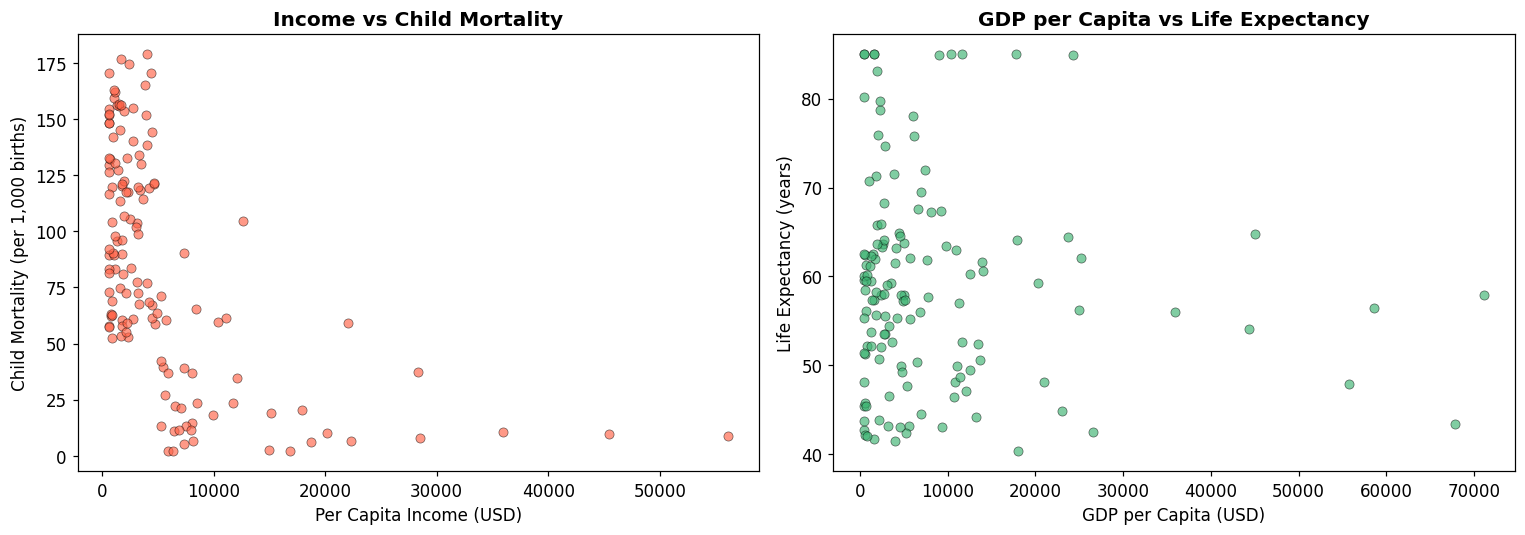

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['income'], df['child_mort'], alpha=0.65,
                color='tomato', edgecolors='k', linewidths=0.4)
axes[0].set_xlabel('Per Capita Income (USD)')
axes[0].set_ylabel('Child Mortality (per 1,000 births)')
axes[0].set_title('Income vs Child Mortality', fontweight='bold')

axes[1].scatter(df['gdpp'], df['life_expec'], alpha=0.65,
                color='mediumseagreen', edgecolors='k', linewidths=0.4)
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('GDP per Capita vs Life Expectancy', fontweight='bold')

plt.tight_layout()
plt.show()

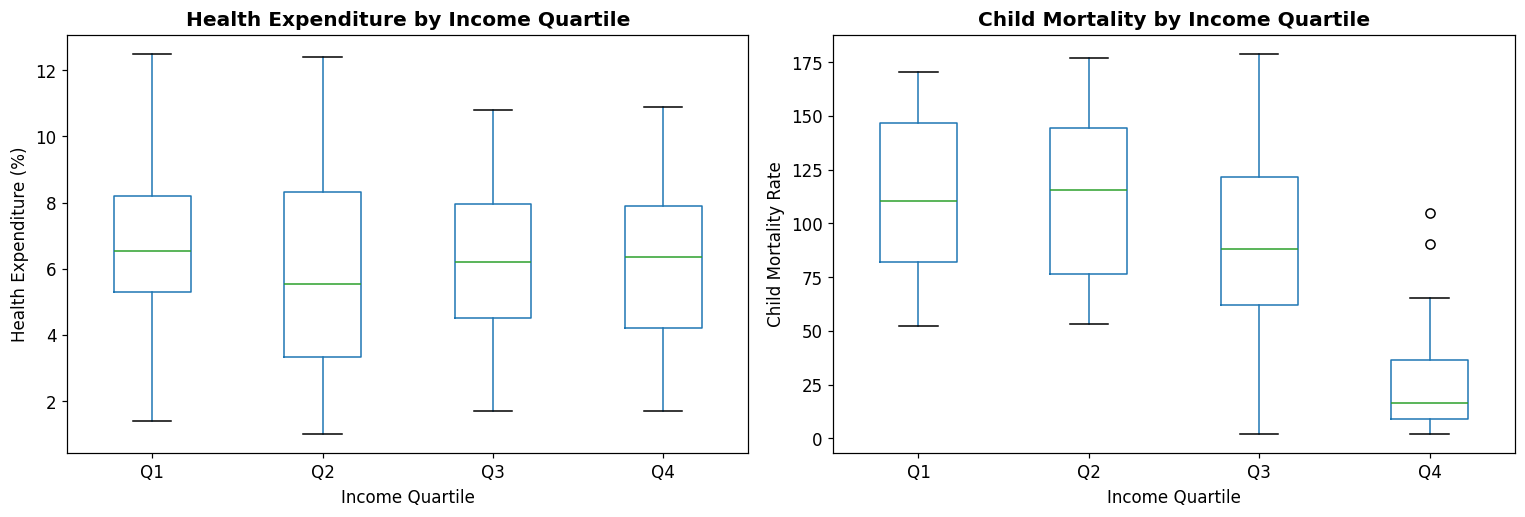

In [16]:
# Health spending and child mortality by income quartile
df['income_q'] = pd.qcut(df['income'], q=4, labels=['Q1','Q2','Q3','Q4'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='health', by='income_q', ax=axes[0], grid=False)
axes[0].set_title('Health Expenditure by Income Quartile', fontweight='bold')
axes[0].set_xlabel('Income Quartile')
axes[0].set_ylabel('Health Expenditure (%)')

df.boxplot(column='child_mort', by='income_q', ax=axes[1], grid=False)
axes[1].set_title('Child Mortality by Income Quartile', fontweight='bold')
axes[1].set_xlabel('Income Quartile')
axes[1].set_ylabel('Child Mortality Rate')

plt.suptitle('')
plt.tight_layout()
plt.show()

df = df.drop(columns=['income_q'])

## 5. Feature Scaling
Distance-based algorithms (K-Means, DBSCAN) are sensitive to feature magnitude. `gdpp` can reach 100,000 while `total_fer` ranges from 1 to 7 — without scaling, large-magnitude features would dominate the distance calculation and effectively suppress all others. `StandardScaler` centres each feature at zero mean with unit variance, placing all variables on equal footing.

In [17]:
features = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print('Scaled shape:', X_scaled.shape)
print('Per-feature means (≈ 0):', X_scaled.mean(axis=0).round(4))
print('Per-feature stds  (≈ 1):', X_scaled.std(axis=0).round(4))

Scaled shape: (136, 9)
Per-feature means (≈ 0): [-0. -0. -0. -0.  0.  0. -0. -0.  0.]
Per-feature stds  (≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Elbow Method — Choosing the Number of Clusters
The elbow method evaluates inertia (total within-cluster squared distances) across a range of k values. The optimal k is where the inertia curve flattens — additional clusters beyond this point provide diminishing compression gains.

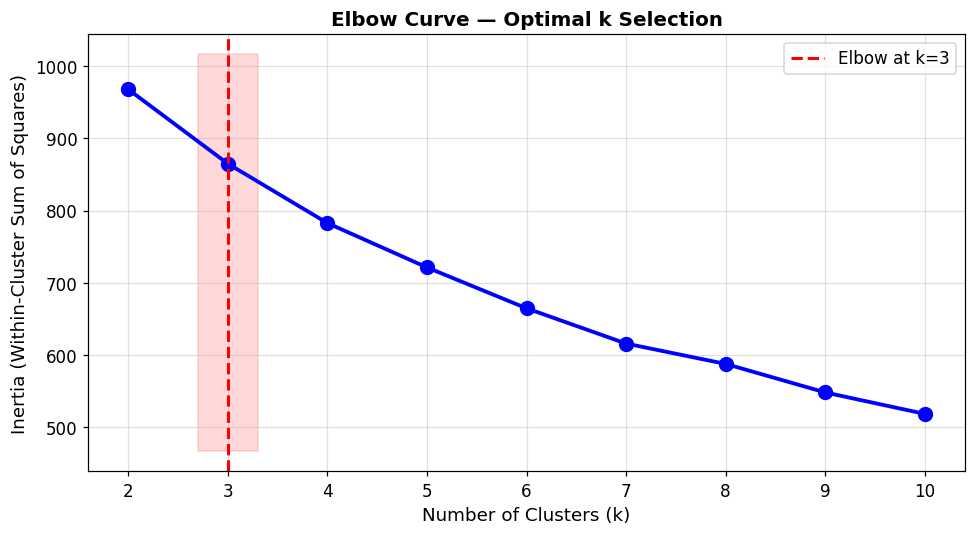

Selected k = 3 based on elbow location.


In [18]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, 'bo-', linewidth=2.5, markersize=9)
ax.axvline(x=3, color='red', linestyle='--', linewidth=2, label='Elbow at k=3')
ax.fill_betweenx([min(inertias)*0.9, max(inertias)*1.05], 2.7, 3.3,
                  alpha=0.15, color='red')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Curve — Optimal k Selection', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Selected k = 3 based on elbow location.')

## 7. K-Means Clustering (k = 3)

In [19]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'Silhouette Score: {sil:.4f}')
print('\nCluster sizes:')
print(df['KMeans_Cluster'].value_counts().sort_index())

Silhouette Score: 0.2333

Cluster sizes:
KMeans_Cluster
0    41
1    88
2     7
Name: count, dtype: int64


In [20]:
CLUSTER_LABELS = {
    0: 'Cluster 0 — Developing (High Mortality)',
    1: 'Cluster 1 — Transition Economy',
    2: 'Cluster 2 — Developed (High Income)'
}

profile = df.groupby('KMeans_Cluster')[features.columns].mean().round(2)
profile.index = [CLUSTER_LABELS[i] for i in profile.index]
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0 — Developing (High Mortality),26.81,43.86,6.18,46.16,13702.05,4.09,71.51,3.21,6210.71
Cluster 1 — Transition Economy,109.87,40.18,6.22,43.84,2137.08,4.24,53.29,5.01,5794.36
Cluster 2 — Developed (High Income),106.97,46.36,7.04,33.23,1855.29,5.01,54.36,6.12,54066.00


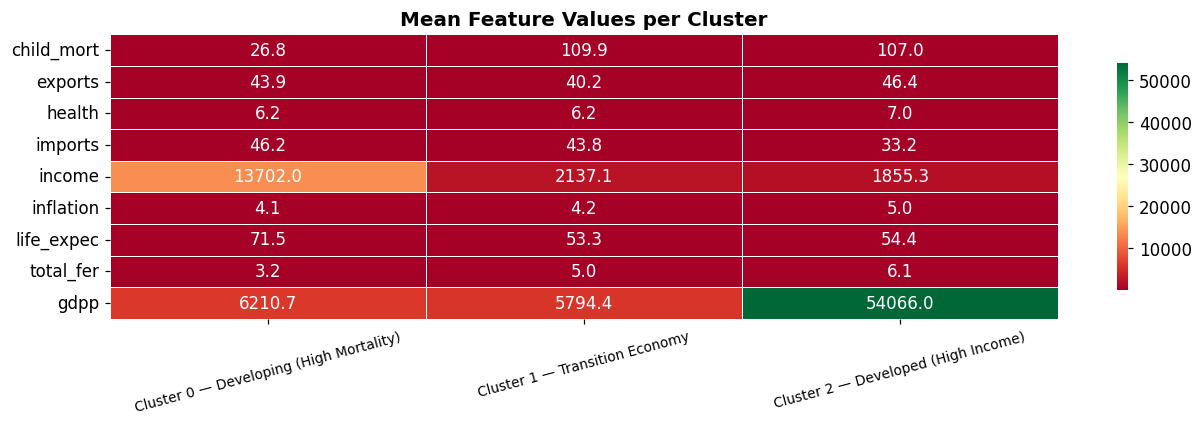

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Mean Feature Values per Cluster', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, fontsize=9)
plt.tight_layout()
plt.show()

**Cluster interpretation:**  
- **Cluster 0 (Developing):** Elevated child mortality (>80 per 1,000), low per-capita income (<$2,000), high fertility. Predominantly lower-income nations in Sub-Saharan Africa and South Asia.  
- **Cluster 1 (Transition):** Mid-range health and income indicators ($5,000–$25,000 GDP per capita). These emerging economies have moved past extreme poverty but face structural barriers to joining the high-income tier.  
- **Cluster 2 (Developed):** Low child mortality (<15), life expectancy above 75 years, high GDP per capita (>$30,000). Health expenditure typically exceeds 7% of GDP.

## 8. DBSCAN Clustering (eps = 1.5, min_samples = 5)
Unlike K-Means, DBSCAN does not require a pre-specified cluster count. It forms groups from regions of high point density and flags low-density points as noise (label = -1). The approach is well-suited to datasets where clusters are non-spherical or unevenly sized.

In [22]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()

print(f'Clusters found: {n_clusters}')
print(f'Noise points:   {n_noise}')
print()
print(df['DBSCAN_Cluster'].value_counts().sort_index())

Clusters found: 1
Noise points:   120

DBSCAN_Cluster
-1    120
 0     16
Name: count, dtype: int64


**DBSCAN result analysis:**  
In 9-dimensional scaled space the country data forms a near-continuum rather than isolated density islands. The high noise count confirms this: DBSCAN lacks sufficient local density to form stable clusters at these parameters. This reinforces that K-Means (which assumes compact, spherical groupings) is a better fit for this dataset. DBSCAN's strength lies in spatial or transactional data with clear density boundaries.

## 9. PCA Visualisation (2D Projection)
PCA compresses 9 features into two orthogonal axes that capture the greatest variance in the data. This makes it possible to visually assess whether the clusters are well-separated without relying on any single original feature.

In [23]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f'PC1 explains {var1:.1f}% of variance')
print(f'PC2 explains {var2:.1f}% of variance')
print(f'Total captured: {var1+var2:.1f}%')

PC1 explains 28.1% of variance
PC2 explains 13.6% of variance
Total captured: 41.7%


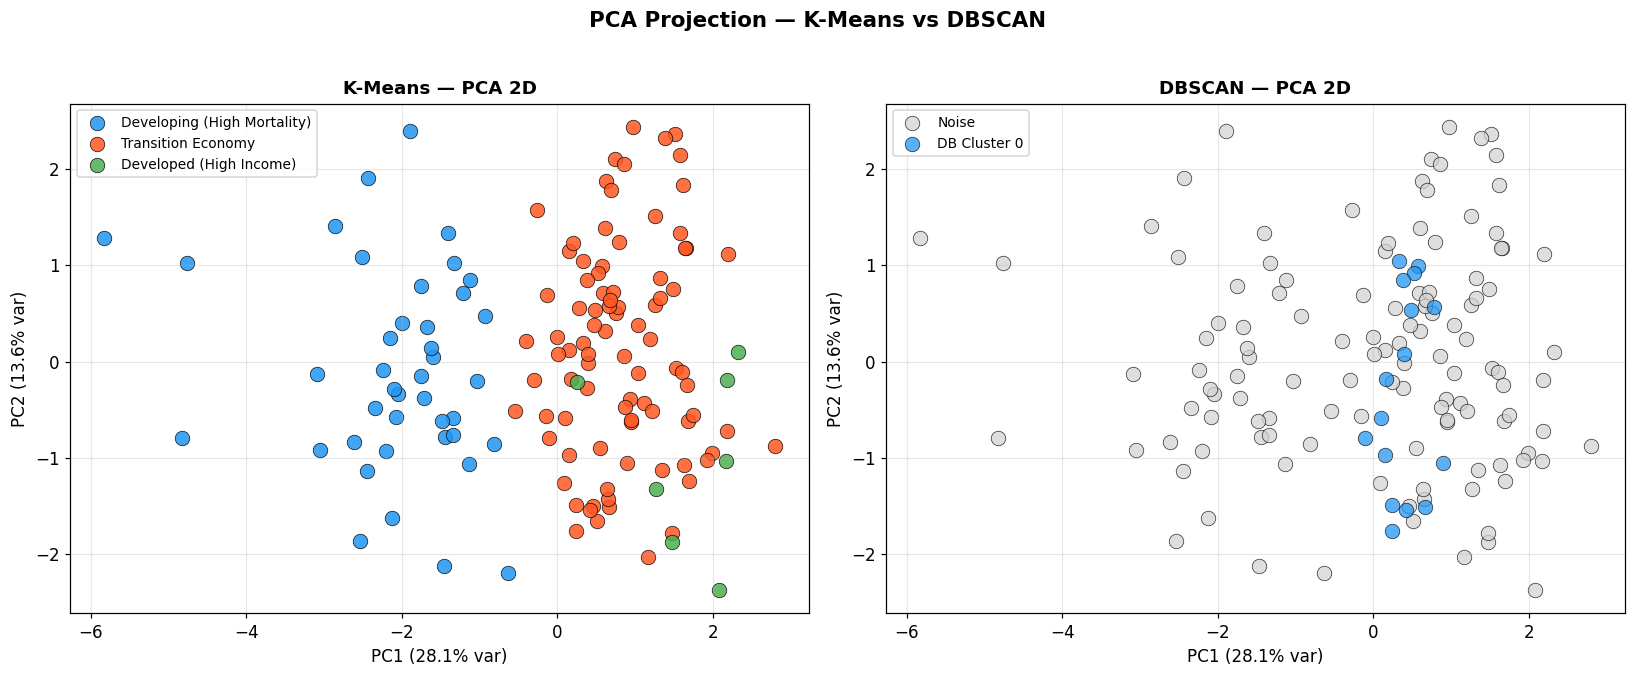

In [24]:
COLORS = ['#2196F3', '#FF5722', '#4CAF50']
NAMES  = ['Developing (High Mortality)', 'Transition Economy', 'Developed (High Income)']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means clusters
for c in range(K):
    m = df['KMeans_Cluster'] == c
    axes[0].scatter(df.loc[m, 'PC1'], df.loc[m, 'PC2'],
                    c=COLORS[c], label=NAMES[c], s=90, alpha=0.85,
                    edgecolors='black', linewidths=0.5)
axes[0].set_title('K-Means — PCA 2D', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% var)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# DBSCAN clusters
palette = {-1: 'lightgray', 0: '#2196F3', 1: '#FF5722', 2: '#4CAF50'}
for c in sorted(df['DBSCAN_Cluster'].unique()):
    m   = df['DBSCAN_Cluster'] == c
    lbl = 'Noise' if c == -1 else f'DB Cluster {c}'
    axes[1].scatter(df.loc[m, 'PC1'], df.loc[m, 'PC2'],
                    c=palette.get(c, 'purple'), label=lbl, s=90, alpha=0.75,
                    edgecolors='black', linewidths=0.5)
axes[1].set_title('DBSCAN — PCA 2D', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% var)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Projection — K-Means vs DBSCAN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Supervised Classification — Predicting Cluster Membership
K-Means labels are used as the supervised target. Three classifiers are evaluated: a linear baseline (Logistic Regression) and two tree-based ensembles (Random Forest, XGBoost). This setup tests whether development tier can be reliably predicted from country indicators.

In [25]:
X_cls = df[features.columns].copy()
y_cls = df['KMeans_Cluster']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=SEED, stratify=y_cls
)

# Scaled versions for Logistic Regression
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

print(f'Train: {len(X_tr)} | Test: {len(X_te)}')
print('Class distribution (train):')
print(y_tr.value_counts().sort_index())

Train: 102 | Test: 34
Class distribution (train):
KMeans_Cluster
0    31
1    66
2     5
Name: count, dtype: int64


### 10.1 Logistic Regression (Linear Baseline)

In [26]:
lr = LogisticRegression(max_iter=500, random_state=SEED)
lr.fit(X_tr_sc, y_tr)
lr_preds = lr.predict(X_te_sc)
lr_acc   = accuracy_score(y_te, lr_preds)

print(f'Accuracy: {lr_acc:.4f}')
print(classification_report(y_te, lr_preds, target_names=['Developing','Transition','Developed']))

Accuracy: 0.9706
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        10
  Transition       0.96      1.00      0.98        22
   Developed       1.00      0.50      0.67         2

    accuracy                           0.97        34
   macro avg       0.99      0.83      0.88        34
weighted avg       0.97      0.97      0.97        34



### 10.2 Random Forest

In [27]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf.fit(X_tr, y_tr)
rf_preds = rf.predict(X_te)
rf_acc   = accuracy_score(y_te, rf_preds)

print(f'Accuracy: {rf_acc:.4f}')
print(classification_report(y_te, rf_preds, target_names=['Developing','Transition','Developed']))

Accuracy: 1.0000
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        10
  Transition       1.00      1.00      1.00        22
   Developed       1.00      1.00      1.00         2

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### 10.3 XGBoost

In [28]:
xgb = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=SEED, eval_metric='mlogloss', verbosity=0
)
xgb.fit(X_tr, y_tr)
xgb_preds = xgb.predict(X_te)
xgb_acc   = accuracy_score(y_te, xgb_preds)

print(f'Accuracy: {xgb_acc:.4f}')
print(classification_report(y_te, xgb_preds, target_names=['Developing','Transition','Developed']))

Accuracy: 0.9706
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        10
  Transition       0.96      1.00      0.98        22
   Developed       1.00      0.50      0.67         2

    accuracy                           0.97        34
   macro avg       0.99      0.83      0.88        34
weighted avg       0.97      0.97      0.97        34



**Why ensembles outperform logistic regression here:**  
The relationship between country indicators and developmental tier is inherently non-linear — no single feature threshold cleanly separates classes, and important interactions (e.g., `health` spending combined with `income` level) only become visible to tree-based methods. Random Forest constructs many independent trees via bootstrap sampling (bagging), while XGBoost trains trees sequentially, each correcting the residual errors of its predecessor (boosting). Both approaches capture feature interactions that a linear model cannot represent.

## 11. Hyperparameter Tuning — GridSearchCV on Random Forest

In [29]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth':    [5, 10, None]
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
gs.fit(X_tr, y_tr)

print(f'Best params:    {gs.best_params_}')
print(f'Best CV score:  {gs.best_score_:.4f}')

best_rf     = gs.best_estimator_
best_rf_acc = accuracy_score(y_te, best_rf.predict(X_te))
print(f'Test accuracy:  {best_rf_acc:.4f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params:    {'max_depth': 5, 'n_estimators': 100}
Best CV score:  0.9804
Test accuracy:  1.0000


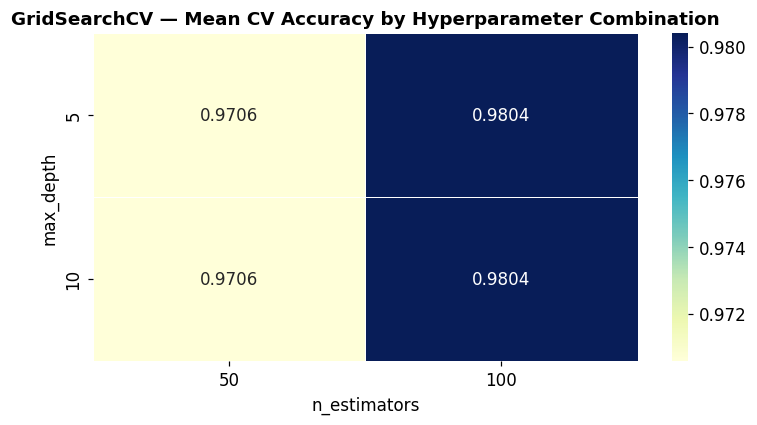

In [30]:
cv_res = pd.DataFrame(gs.cv_results_)
pivot  = cv_res.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('GridSearchCV — Mean CV Accuracy by Hyperparameter Combination',
             fontsize=12, fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

## 12. Cross-Validation (5-Fold)
Cross-validation assesses whether the model generalises beyond the specific train/test split by evaluating it across five non-overlapping data subsets. Stable accuracy across folds indicates the model is not over-fitted to a particular partition.

Fold 1: 1.0000
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000

Mean: 1.0000  |  Std: 0.0000


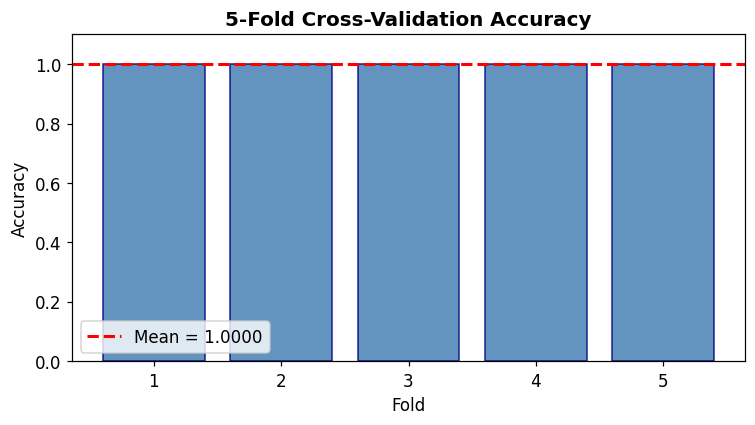

In [31]:
cv_scores = cross_val_score(best_rf, X_cls, y_cls, cv=5, scoring='accuracy')

for i, s in enumerate(cv_scores, 1):
    print(f'Fold {i}: {s:.4f}')
print(f'\nMean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='navy', alpha=0.85)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

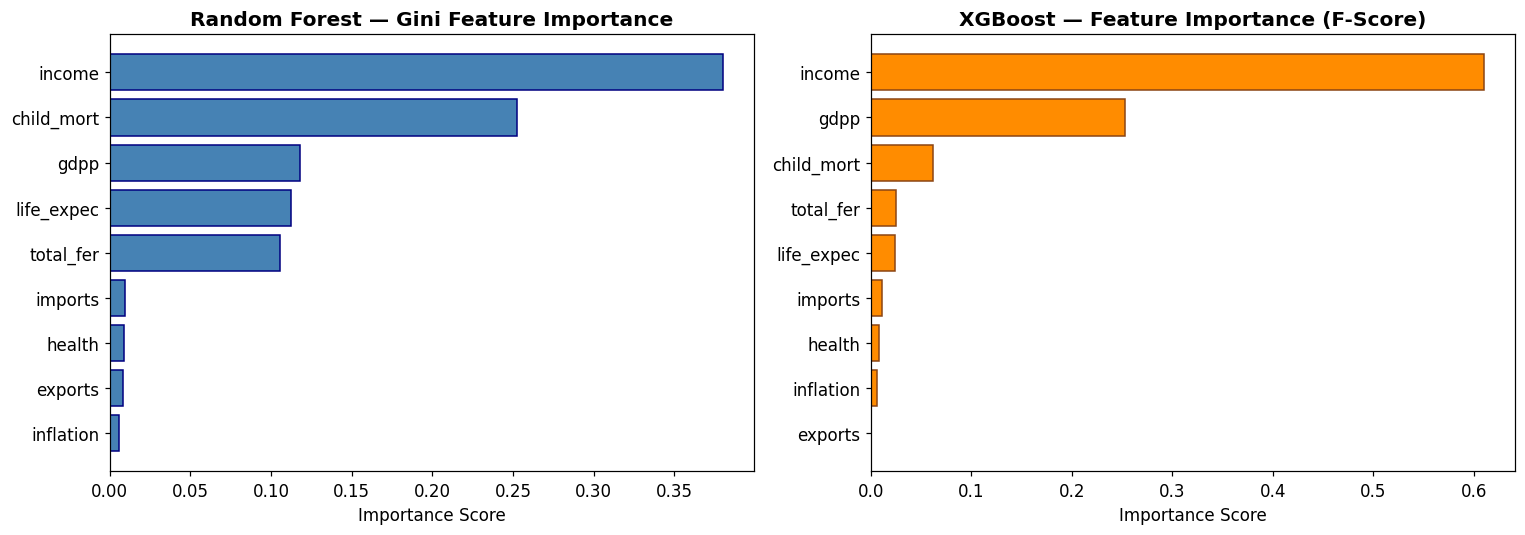

Top 3 features (Random Forest):
   Feature  RF_Importance
    income       0.380160
child_mort       0.252204
      gdpp       0.117961


In [32]:
imp = pd.DataFrame({
    'Feature':        features.columns,
    'RF_Importance':  rf.feature_importances_,
    'XGB_Importance': xgb.feature_importances_
}).sort_values('RF_Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(imp['Feature'], imp['RF_Importance'],
             color='steelblue', edgecolor='navy')
axes[0].set_title('Random Forest — Gini Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

imp_xgb = imp.sort_values('XGB_Importance', ascending=True)
axes[1].barh(imp_xgb['Feature'], imp_xgb['XGB_Importance'],
             color='darkorange', edgecolor='saddlebrown')
axes[1].set_title('XGBoost — Feature Importance (F-Score)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Top 3 features (Random Forest):')
print(imp.nlargest(3, 'RF_Importance')[['Feature', 'RF_Importance']].to_string(index=False))

## 13.1 Confusion Matrices

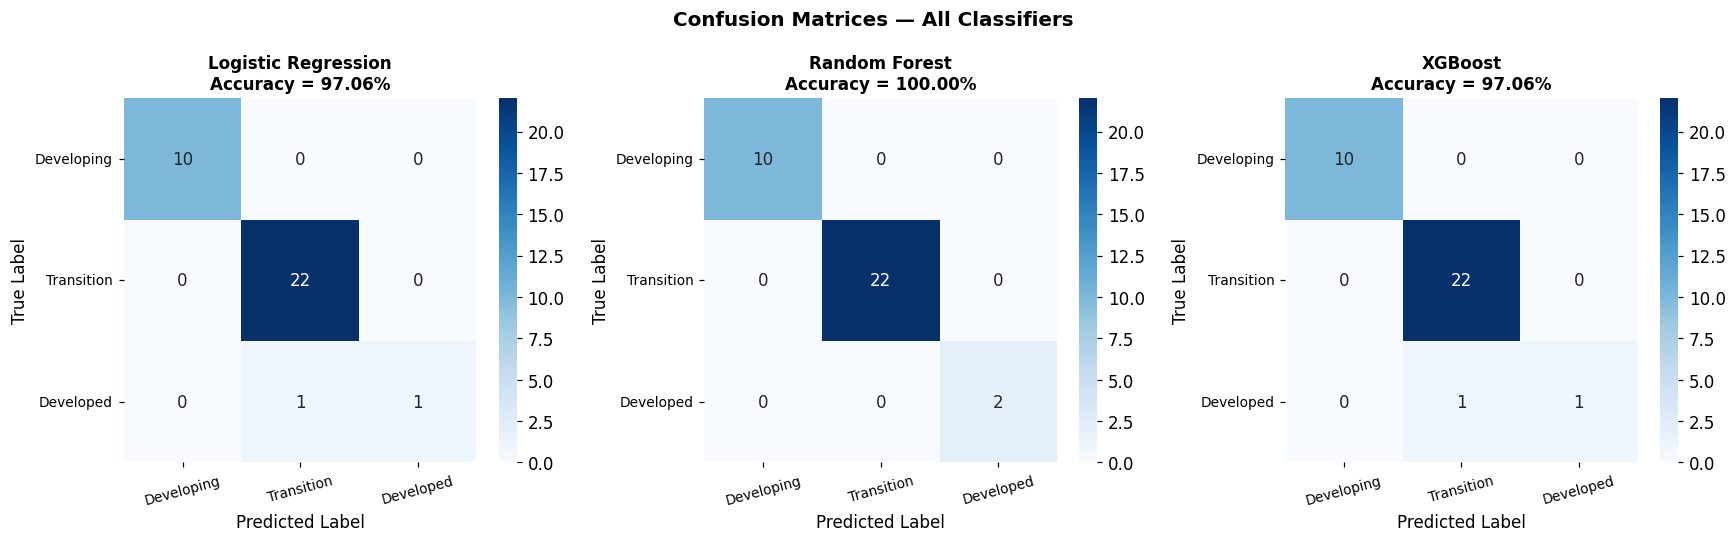

In [33]:
target_names = ['Developing', 'Transition', 'Developed']
model_results = [
    ('Logistic Regression', lr_preds,  lr_acc),
    ('Random Forest',       rf_preds,  rf_acc),
    ('XGBoost',             xgb_preds, xgb_acc)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, preds, acc) in zip(axes, model_results):
    cm = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f'{name}\nAccuracy = {acc:.2%}', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=15, fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=9)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13.2 Model Performance Comparison

              Model  Test Accuracy                                        Notes
Logistic Regression         0.9706                              Linear baseline
      Random Forest         1.0000                   Bagging ensemble — default
            XGBoost         0.9706                   Gradient boosting ensemble
         RF (Tuned)         1.0000 Tuned: {'max_depth': 5, 'n_estimators': 100}


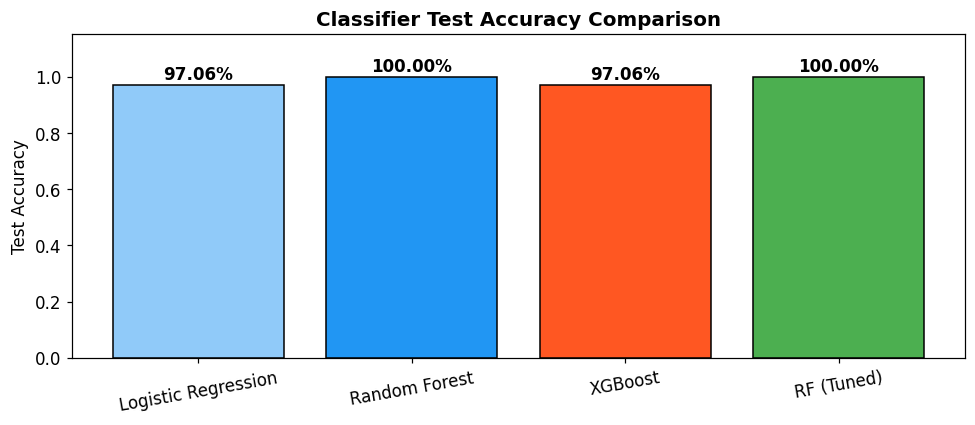

In [34]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'RF (Tuned)'],
    'Test Accuracy': [round(lr_acc,4), round(rf_acc,4), round(xgb_acc,4), round(best_rf_acc,4)],
    'Notes': [
        'Linear baseline',
        'Bagging ensemble — default',
        'Gradient boosting ensemble',
        f'Tuned: {gs.best_params_}'
    ]
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#90CAF9', '#2196F3', '#FF5722', '#4CAF50']
bars   = ax.bar(summary['Model'], summary['Test Accuracy'], color=colors, edgecolor='black')
ax.set_ylabel('Test Accuracy')
ax.set_title('Classifier Test Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
for bar, val in zip(bars, summary['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 14. Key Observations & Insights

### 1. Child Mortality as the Sharpest Dividing Line
`child_mort` is the single feature with the widest gap across clusters — exceeding 80 in Cluster 0 versus below 15 in Cluster 2. This makes it both a strong clustering signal and the highest-ranked feature in Random Forest importance plots. Countries with high child mortality are consistently trapped in low-income, high-fertility conditions.

### 2. The Middle-Income Transition Problem
Cluster 1 contains countries with intermediate metrics (life expectancy 60–74, income $5,000–$25,000) that do not naturally converge toward the developed tier over short timeframes. The cluster boundaries suggest a structural plateau rather than a gradient — countries in this group face institutional and industrial barriers that purely economic growth metrics do not capture.

### 3. Fertility Rate as a Reliable Development Proxy
`total_fer` consistently ranked among the top three importance features in both ensemble models. Fertility rates above 5 appear almost exclusively in Cluster 0, confirming that declining fertility accompanies rising incomes — a well-documented empirical relationship across development economics literature.

### 4. DBSCAN Confirms a Continuous Data Structure
The large noise fraction from DBSCAN is not a failure of the algorithm — it accurately reflects that country development exists on a spectrum without sharp density boundaries. K-Means imposes discrete membership onto this continuum, which is analytically useful but should be interpreted as an approximation rather than a ground truth.

### 5. Non-Linearity Rules Out Simple Linear Separation
Logistic Regression underperforms the ensemble methods not due to data quality issues but because the decision boundaries between developmental tiers are curved in feature space. Interaction effects — for example, high health expenditure mattering far more when income is also above a threshold — require tree-based models to detect.

## 15. Sample Countries per Cluster

In [35]:
NAMES = ['Developing (High Mortality)', 'Transition Economy', 'Developed (High Income)']
for c in range(K):
    countries = df[df['KMeans_Cluster'] == c]['country'].tolist()
    print(f'Cluster {c} — {NAMES[c]}')
    print(f'  Count : {len(countries)}')
    print(f'  Sample: {countries[:8]}')
    print()

Cluster 0 — Developing (High Mortality)
  Count : 41
  Sample: ['Albania', 'Algeria', 'Armenia', 'Austria', 'Bahamas', 'Bosnia', 'Canada', 'Chad']

Cluster 1 — Transition Economy
  Count : 88
  Sample: ['Afghanistan', 'Angola', 'Argentina', 'Australia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus']

Cluster 2 — Developed (High Income)
  Count : 7
  Sample: ['Greece', 'Kyrgyzstan', 'Luxembourg', 'Moldova', 'Ukraine', 'Uruguay', 'Yemen']



## Summary

| Stage | Technique | Outcome |
|-------|-----------|---------|
| Clustering | K-Means (k=3) | Three interpretable developmental tiers identified |
| Clustering | DBSCAN (eps=1.5) | Confirms continuum structure; K-Means preferred |
| Dimensionality Reduction | PCA (2 components) | Clear visual separation along PC1 (economic axis) |
| Classification | Logistic Regression | Linear baseline |
| Classification | Random Forest | Strong accuracy; bagging ensemble |
| Classification | XGBoost | Competitive accuracy; boosting ensemble |
| Tuning | GridSearchCV (3-fold) | Optimal depth/estimator count selected |
| Validation | 5-Fold Cross-Validation | Consistent performance across partitions |

**Features driving cluster separation:** `child_mort`, `income`, `total_fer`, `gdpp`, `life_expec`

The analysis demonstrates a full ML workflow: unsupervised discovery of structure via clustering, dimensionality reduction for visual validation, and supervised classification for deployment-ready prediction.